In [42]:
# 导入所需的包
import pandas as pd  # 导入pandas数据处理库


# 导入所有数据（包括上下文变量）
from pandas.api.types import CategoricalDtype
cat_size_order = CategoricalDtype(
    ['MQ', 'MEFFCH', 'MTECHCH'],  # 分类顺序：
    ordered=True
)



import pandas as pd  # 导入pandas数据处理库
# 导入所有数据（包括上下文变量）

kind = "province"  # 当前设置为省份级分析

if kind == "province":
    dmuname = '省份'  # 设置决策单元名称为"省份"
    data = pd.read_excel(r"../../data\china data.xlsx").query('year>2015').reset_index(drop=True)
    region = data[["省份","group"]]  # 提取省份和区域分组信息
else:
    dmuname = '国家'  # 设置决策单元名称为"国家"
    data = pd.read_excel(r"../../data\oecd data.xlsx").query('year>2015').reset_index(drop=True)


yearid = data[['year', dmuname]]  # 选择年份和DMU名称列
yearid

,year,省份
0,2016,上海市
1,2017,上海市
2,2018,上海市
3,2019,上海市
4,2016,云南省
...,...,...
115,2019,青海省
116,2016,黑龙江省
117,2017,黑龙江省
118,2018,黑龙江省


In [43]:
data

,省份,year,Y,E,L,K,CO2,group
0,上海市,2016,902.794998,11286.777262,1365.24,4.085533e+06,188.140000,E
1,上海市,2017,929.498785,11423.298889,1372.65,4.238459e+06,190.480000,E
2,上海市,2018,951.911601,11072.057032,1375.66,5.790083e+06,190.641610,E
3,上海市,2019,947.300532,11536.380416,1376.20,6.373635e+06,192.912182,E
4,云南省,2016,427.550554,9360.041199,2855.00,4.787612e+06,180.050000,W
...,...,...,...,...,...,...,...,...
115,青海省,2019,62.322152,3566.776509,330.20,1.164860e+06,51.752403,W
116,黑龙江省,2016,394.193978,9307.525536,1776.00,4.500560e+06,269.340000,C
117,黑龙江省,2017,384.949317,9192.427176,1699.00,4.867986e+06,268.660000,C
118,黑龙江省,2018,384.333468,7514.188572,1635.00,4.611428e+06,248.035933,C


In [44]:
yearid[dmuname].unique()  # 显示所有唯一的决策单元名称

array(['上海市', '云南省', '内蒙古自治区', '北京市', '吉林省', '四川省', '天津市', '宁夏回族自治区',
       '安徽省', '山东省', '山西省', '广东省', '广西壮族自治区', '新疆维吾尔自治区', '江苏省', '江西省',
       '河北省', '河南省', '浙江省', '海南省', '湖北省', '湖南省', '甘肃省', '福建省', '贵州省',
       '辽宁省', '重庆市', '陕西省', '青海省', '黑龙江省'], dtype=object)

## CNLSSDb

In [45]:
from deabook import CNLSSDFDDFweak, StoNED  # 导入CNLS方向性距离函数和随机非参数包络分析类
from deabook.constant import FUN_PROD, OPT_LOCAL,RTS_VRS1 ,RTS_CRS,CET_ADDI, CET_MULT,RED_QLE

# 定义并求解DEA模型
def CNLSSDb_CRS():

    model = CNLSSDFDDFweak.CNLSSDweak(data,sent = "K L E=Y:CO2", \
                               gy=[0],gx=[0,0,0],gb=[1], \
                                cet=CET_MULT, rts=RTS_CRS, fun=FUN_PROD, \
                              )
    # model.optimize( email= '1019753743@qq.com',)
    model.optimize(solver="knitro",)

    rd = StoNED.StoNED(model)  # 创建StoNED对象
    res=rd.get_technical_efficiency(RED_QLE)
    return res
CNLSSDb_CRS = CNLSSDb_CRS()
CNLSSDb_CRS

Optimizing locally.
Estimating the multiplicative model locally with knitro solver.
Artelys Knitro 14.2.0: 
          Commercial License
         Artelys Knitro 14.2.0

Knitro using up to 16 threads.
No start point provided -- Knitro computing one.

Knitro presolve eliminated 120 variables and 120 constraints.

concurrent_evals         0
datacheck                0
findiff_numthreads       1
hessian_no_f             1
hessopt                  1
Knitro fixing 120 variables eliminated from the presolve.

Problem Characteristics                                 (   Presolved)
-----------------------
Objective goal:  Minimize
Objective type:  quadratic
Number of variables:                                840 (         720)
    bounded below only:                             720 (         600)
    bounded above only:                               0 (           0)
    bounded below and above:                          0 (           0)
    fixed:                                            0 (    

array([0.10659141, 0.10791624, 0.10800774, 0.10929326, 0.10201102,
       0.11019222, 0.1202379 , 0.10535484, 0.33387182, 0.36188177,
       0.40952025, 0.44936686, 0.0506357 , 0.04816591, 0.05076751,
       0.04997035, 0.11387221, 0.11555365, 0.11118146, 0.11537903,
       0.17545358, 0.17527247, 0.16782396, 0.17849478, 0.08304811,
       0.07984866, 0.08731366, 0.08979017, 0.07737398, 0.09921968,
       0.10854414, 0.12033395, 0.20520557, 0.20984042, 0.22593132,
       0.23106954, 0.47092765, 0.45590502, 0.50920526, 0.52862255,
       0.25451052, 0.27629467, 0.30673735, 0.32070444, 0.29307611,
       0.30712416, 0.32128301, 0.33163762, 0.11963547, 0.1249853 ,
       0.13132724, 0.13975268, 0.20974422, 0.22854893, 0.2386929 ,
       0.25778364, 0.40975819, 0.41672354, 0.43235436, 0.45516079,
       0.12084132, 0.12689308, 0.13404244, 0.13725719, 0.42357783,
       0.41084782, 0.51500938, 0.51610932, 0.29042824, 0.27992713,
       0.27781565, 0.26081437, 0.21068363, 0.21639362, 0.22018

In [46]:
from deabook import CNLSSDFDDFweak, StoNED  # 导入CNLS方向性距离函数和随机非参数包络分析类
from deabook.constant import FUN_PROD, OPT_LOCAL,RTS_VRS1,RTS_VRS2 ,RTS_CRS,CET_ADDI, CET_MULT,RED_QLE

# 定义并求解DEA模型
def CNLSSDb_VRS_SAME():

    model = CNLSSDFDDFweak.CNLSSDweak(data,sent = "K L E=Y:CO2", \
                               gy=[0],gx=[0,0,0],gb=[1], \
                                cet=CET_MULT, rts=RTS_VRS1, fun=FUN_PROD, \
                              )
    # model.optimize( email= '1019753743@qq.com',)
    model.optimize(solver="knitro",)

    rd = StoNED.StoNED(model)  # 创建StoNED对象
    res=rd.get_technical_efficiency(RED_QLE)
    return res
CNLSSDb_VRS_SAME = CNLSSDb_VRS_SAME()
CNLSSDb_VRS_SAME

Optimizing locally.
Estimating the multiplicative model locally with knitro solver.
Artelys Knitro 14.2.0: 
          Commercial License
         Artelys Knitro 14.2.0

Knitro using up to 16 threads.
No start point provided -- Knitro computing one.

Knitro presolve eliminated 120 variables and 120 constraints.

concurrent_evals         0
datacheck                0
findiff_numthreads       1
hessian_no_f             1
hessopt                  1
Knitro fixing 120 variables eliminated from the presolve.

Problem Characteristics                                 (   Presolved)
-----------------------
Objective goal:  Minimize
Objective type:  quadratic
Number of variables:                                960 (         840)
    bounded below only:                             840 (         720)
    bounded above only:                               0 (           0)
    bounded below and above:                          0 (           0)
    fixed:                                            0 (    

array([0.10659145, 0.10791628, 0.10800778, 0.1092933 , 0.10201105,
       0.11019225, 0.12023794, 0.10535488, 0.33387191, 0.36188186,
       0.40952032, 0.44936685, 0.05063572, 0.04816593, 0.05076753,
       0.04997037, 0.11387224, 0.11555369, 0.11118149, 0.11537907,
       0.17545364, 0.17527252, 0.16782401, 0.17849483, 0.08304814,
       0.07984869, 0.0873137 , 0.0897902 , 0.07737401, 0.09921972,
       0.10854418, 0.12033399, 0.20520563, 0.20984049, 0.22593139,
       0.23106961, 0.47092756, 0.45590499, 0.50920491, 0.52862199,
       0.25451059, 0.27629475, 0.30673743, 0.32070452, 0.29307619,
       0.30712425, 0.3212831 , 0.33163771, 0.11963551, 0.12498534,
       0.13132728, 0.13975273, 0.20974428, 0.228549  , 0.23869297,
       0.25778371, 0.40975826, 0.4167236 , 0.43235439, 0.45516076,
       0.12084136, 0.12689312, 0.13404248, 0.13725723, 0.42357788,
       0.41084788, 0.51500897, 0.5161089 , 0.29042832, 0.2799272 ,
       0.27781572, 0.26081444, 0.21068369, 0.21639368, 0.22018

In [47]:
from deabook import CNLSSDFDDFweak, StoNED  # 导入CNLS方向性距离函数和随机非参数包络分析类
from deabook.constant import FUN_PROD, OPT_LOCAL,RTS_VRS1,RTS_VRS2 ,RTS_CRS,CET_ADDI, CET_MULT,RED_QLE

# 定义并求解DEA模型
def CNLSSDb_VRS_DIFF():

    model = CNLSSDFDDFweak.CNLSSDweak(data,sent = "K L E=Y:CO2", \
                               gy=[0],gx=[0,0,0],gb=[1], \
                                cet=CET_MULT, rts=RTS_VRS2, fun=FUN_PROD, \
                              )
    # model.optimize( email= '1019753743@qq.com',)
    model.optimize(solver="knitro",)

    rd = StoNED.StoNED(model)  # 创建StoNED对象
    res=rd.get_technical_efficiency(RED_QLE)
    return res
CNLSSDb_VRS_DIFF = CNLSSDb_VRS_DIFF()
CNLSSDb_VRS_DIFF

Optimizing locally.
Estimating the multiplicative model locally with knitro solver.
Artelys Knitro 14.2.0: 
          Commercial License
         Artelys Knitro 14.2.0

Knitro using up to 16 threads.
No start point provided -- Knitro computing one.

Knitro presolve eliminated 120 variables and 120 constraints.

concurrent_evals         0
datacheck                0
findiff_numthreads       1
hessian_no_f             1
hessopt                  1
Knitro fixing 120 variables eliminated from the presolve.

Problem Characteristics                                 (   Presolved)
-----------------------
Objective goal:  Minimize
Objective type:  quadratic
Number of variables:                                960 (         840)
    bounded below only:                             720 (         600)
    bounded above only:                               0 (           0)
    bounded below and above:                          0 (           0)
    fixed:                                            0 (    

array([0.10659145, 0.10791629, 0.10800779, 0.1092933 , 0.10201106,
       0.11019226, 0.12023794, 0.10535488, 0.33387193, 0.36188187,
       0.40952033, 0.44936685, 0.05063572, 0.04816593, 0.05076754,
       0.04997038, 0.11387225, 0.1155537 , 0.1111815 , 0.11537908,
       0.17545365, 0.17527253, 0.16782402, 0.17849484, 0.08304814,
       0.07984869, 0.0873137 , 0.08979021, 0.07737402, 0.09921972,
       0.10854419, 0.120334  , 0.20520564, 0.2098405 , 0.2259314 ,
       0.23106962, 0.47092754, 0.45590498, 0.50920484, 0.52862188,
       0.25451061, 0.27629476, 0.30673745, 0.32070454, 0.2930762 ,
       0.30712426, 0.32128311, 0.33163772, 0.11963552, 0.12498534,
       0.13132729, 0.13975274, 0.20974429, 0.22854901, 0.23869298,
       0.25778373, 0.40975827, 0.41672361, 0.4323544 , 0.45516076,
       0.12084137, 0.12689313, 0.13404249, 0.13725724, 0.42357789,
       0.41084789, 0.51500889, 0.51610882, 0.29042834, 0.27992722,
       0.27781574, 0.26081446, 0.21068371, 0.21639369, 0.22018

In [48]:
CNLSSDb_CRS2 = pd.DataFrame(CNLSSDb_CRS,columns=['TE'])
CNLSSDb_CRS2 = pd.concat([data,CNLSSDb_CRS2], axis=1)
CNLSSDb_VRS_SAME2 = pd.DataFrame(CNLSSDb_VRS_SAME,columns=['TE']) 
CNLSSDb_VRS_SAME2 = pd.concat([data,CNLSSDb_VRS_SAME2], axis=1)

CNLSSDb_VRS_DIFF2 = pd.DataFrame(CNLSSDb_VRS_DIFF,columns=['TE']) 
CNLSSDb_VRS_DIFF2 = pd.concat([data,CNLSSDb_VRS_DIFF2], axis=1)

In [49]:
CNLSSDb_CRS2

,省份,year,Y,E,L,K,CO2,group,TE
0,上海市,2016,902.794998,11286.777262,1365.24,4.085533e+06,188.140000,E,0.106591
1,上海市,2017,929.498785,11423.298889,1372.65,4.238459e+06,190.480000,E,0.107916
2,上海市,2018,951.911601,11072.057032,1375.66,5.790083e+06,190.641610,E,0.108008
3,上海市,2019,947.300532,11536.380416,1376.20,6.373635e+06,192.912182,E,0.109293
4,云南省,2016,427.550554,9360.041199,2855.00,4.787612e+06,180.050000,W,0.102011
...,...,...,...,...,...,...,...,...,...
115,青海省,2019,62.322152,3566.776509,330.20,1.164860e+06,51.752403,W,0.029346
116,黑龙江省,2016,394.193978,9307.525536,1776.00,4.500560e+06,269.340000,C,0.152559
117,黑龙江省,2017,384.949317,9192.427176,1699.00,4.867986e+06,268.660000,C,0.152174
118,黑龙江省,2018,384.333468,7514.188572,1635.00,4.611428e+06,248.035933,C,0.140499


In [50]:
CNLSSDb_VRS_SAME2

,省份,year,Y,E,L,K,CO2,group,TE
0,上海市,2016,902.794998,11286.777262,1365.24,4.085533e+06,188.140000,E,0.106591
1,上海市,2017,929.498785,11423.298889,1372.65,4.238459e+06,190.480000,E,0.107916
2,上海市,2018,951.911601,11072.057032,1375.66,5.790083e+06,190.641610,E,0.108008
3,上海市,2019,947.300532,11536.380416,1376.20,6.373635e+06,192.912182,E,0.109293
4,云南省,2016,427.550554,9360.041199,2855.00,4.787612e+06,180.050000,W,0.102011
...,...,...,...,...,...,...,...,...,...
115,青海省,2019,62.322152,3566.776509,330.20,1.164860e+06,51.752403,W,0.029346
116,黑龙江省,2016,394.193978,9307.525536,1776.00,4.500560e+06,269.340000,C,0.152559
117,黑龙江省,2017,384.949317,9192.427176,1699.00,4.867986e+06,268.660000,C,0.152174
118,黑龙江省,2018,384.333468,7514.188572,1635.00,4.611428e+06,248.035933,C,0.140499


In [51]:
CNLSSDb_VRS_DIFF2

,省份,year,Y,E,L,K,CO2,group,TE
0,上海市,2016,902.794998,11286.777262,1365.24,4.085533e+06,188.140000,E,0.106591
1,上海市,2017,929.498785,11423.298889,1372.65,4.238459e+06,190.480000,E,0.107916
2,上海市,2018,951.911601,11072.057032,1375.66,5.790083e+06,190.641610,E,0.108008
3,上海市,2019,947.300532,11536.380416,1376.20,6.373635e+06,192.912182,E,0.109293
4,云南省,2016,427.550554,9360.041199,2855.00,4.787612e+06,180.050000,W,0.102011
...,...,...,...,...,...,...,...,...,...
115,青海省,2019,62.322152,3566.776509,330.20,1.164860e+06,51.752403,W,0.029346
116,黑龙江省,2016,394.193978,9307.525536,1776.00,4.500560e+06,269.340000,C,0.152559
117,黑龙江省,2017,384.949317,9192.427176,1699.00,4.867986e+06,268.660000,C,0.152174
118,黑龙江省,2018,384.333468,7514.188572,1635.00,4.611428e+06,248.035933,C,0.140500


In [52]:
CNLSSDb_CRS3 = CNLSSDb_CRS2.pivot_table(
    values=['TE'],  # 分析技术效率
    index=dmuname,  # 行索引为决策单元(省份/国家)
    columns='year',  # 列索引为年份
    aggfunc='mean',  # 计算平均值
    fill_value=None,
    margins=False,
    dropna=True,
    margins_name='All',
    observed=False,
)     
CNLSSDb_CRS3

TE                              
year          2016      2017      2018      2019
省份                                              
上海市       0.106591  0.107916  0.108008  0.109293
云南省       0.102011  0.110192  0.120238  0.105355
内蒙古自治区    0.333872  0.361882  0.409520  0.449367
北京市       0.050636  0.048166  0.050768  0.049970
吉林省       0.113872  0.115554  0.111181  0.115379
四川省       0.175454  0.175272  0.167824  0.178495
天津市       0.083048  0.079849  0.087314  0.089790
宁夏回族自治区   0.077374  0.099220  0.108544  0.120334
安徽省       0.205206  0.209840  0.225931  0.231070
山东省       0.470928  0.455905  0.509205  0.528623
山西省       0.254511  0.276295  0.306737  0.320704
广东省       0.293076  0.307124  0.321283  0.331638
广西壮族自治区   0.119635  0.124985  0.131327  0.139753
新疆维吾尔自治区  0.209744  0.228549  0.238693  0.257784
江苏省       0.409758  0.416724  0.432354  0.455161
江西省       0.120841  0.126893  0.134042  0.137257
河北省       0.423578  0.410848  0.515009  0.516109
河南省       0.290428  0.279927  0.277816  0.260814
浙江省       0.210684  0.216394  0.220182  0.215985
海南省       0.022601  0.023910  0.023929  0.024424
湖北省       0.175997  0.183830  0.182571  0.200900
湖南省       0.166386  0.175425  0.173292  0.175936
甘肃省       0.086344  0.085279  0.092352  0.093200
福建省       0.120892  0.130505  0.148096  0.157522
贵州省       0.141056  0.144640  0.143304  0.147911
辽宁省       0.258607  0.271310  0.294962  0.301981
重庆市       0.087040  0.089311  0.091108  0.088538
陕西省       0.150334  0.148381  0.156427  0.167803
青海省       0.032014  0.030178  0.029451  0.029346
黑龙江省      0.152559  0.152174  0.140499  0.157580

In [53]:
CNLSSDb_VRS_SAME3 = CNLSSDb_VRS_SAME2.pivot_table(
    values=['TE'],  # 分析技术效率
    index=dmuname,  # 行索引为决策单元(省份/国家)
    columns='year',  # 列索引为年份
    aggfunc='mean',  # 计算平均值
    fill_value=None,
    margins=False,
    dropna=True,
    margins_name='All',
    observed=False,
)  

In [54]:
CNLSSDb_VRS_DIFF3 = CNLSSDb_VRS_DIFF2.pivot_table(
    values=['TE'],  # 分析技术效率
    index=dmuname,  # 行索引为决策单元(省份/国家)
    columns='year',  # 列索引为年份
    aggfunc='mean',  # 计算平均值
    fill_value=None,
    margins=False,
    dropna=True,
    margins_name='All',
    observed=False,
) 

In [55]:
CNLSSDb_VRS_DIFF3

TE                              
year          2016      2017      2018      2019
省份                                              
上海市       0.106591  0.107916  0.108008  0.109293
云南省       0.102011  0.110192  0.120238  0.105355
内蒙古自治区    0.333872  0.361882  0.409520  0.449367
北京市       0.050636  0.048166  0.050768  0.049970
吉林省       0.113872  0.115554  0.111182  0.115379
四川省       0.175454  0.175273  0.167824  0.178495
天津市       0.083048  0.079849  0.087314  0.089790
宁夏回族自治区   0.077374  0.099220  0.108544  0.120334
安徽省       0.205206  0.209840  0.225931  0.231070
山东省       0.470928  0.455905  0.509205  0.528622
山西省       0.254511  0.276295  0.306737  0.320705
广东省       0.293076  0.307124  0.321283  0.331638
广西壮族自治区   0.119636  0.124985  0.131327  0.139753
新疆维吾尔自治区  0.209744  0.228549  0.238693  0.257784
江苏省       0.409758  0.416724  0.432354  0.455161
江西省       0.120841  0.126893  0.134042  0.137257
河北省       0.423578  0.410848  0.515009  0.516109
河南省       0.290428  0.279927  0.277816  0.260814
浙江省       0.210684  0.216394  0.220183  0.215985
海南省       0.022601  0.023910  0.023929  0.024424
湖北省       0.175997  0.183830  0.182571  0.200900
湖南省       0.166386  0.175425  0.173292  0.175936
甘肃省       0.086344  0.085279  0.092352  0.093200
福建省       0.120892  0.130505  0.148096  0.157522
贵州省       0.141057  0.144640  0.143304  0.147911
辽宁省       0.258607  0.271310  0.294962  0.301981
重庆市       0.087040  0.089311  0.091108  0.088538
陕西省       0.150334  0.148381  0.156427  0.167803
青海省       0.032014  0.030178  0.029451  0.029346
黑龙江省      0.152559  0.152174  0.140500  0.157580

In [56]:
CNLSSDb_CRS3.to_markdown("table_CNLSSDb_CRS3.md")
CNLSSDb_VRS_SAME3.to_markdown("table_CNLSSDb_VRS_SAME3.md")
CNLSSDb_VRS_DIFF3.to_markdown("table_CNLSSDb_VRS_DIFF3.md")

## CNLSDDFb

In [57]:
from deabook import CNLSSDFDDFweak, StoNED  # 导入CNLS方向性距离函数和随机非参数包络分析类
from deabook.constant import FUN_PROD, OPT_LOCAL,RTS_VRS1,RTS_VRS2,RED_MOM,RED_QLE,RTS_CRS

In [58]:
def CNLSDDFb_CRS():

    model = CNLSSDFDDFweak.CNLSDDFweak(data,sent = "K L E=Y:CO2",  gy=[0], gx=[0,0,0],gb=[1],\
                                    fun=FUN_PROD, rts=RTS_CRS)  # 生产函数, 规模报酬不变
    model.optimize( solver="mosek")

    rd = StoNED.StoNED(model)  # 创建StoNED对象
    res=rd.get_technical_efficiency_ratio(RED_QLE)
    return res

CNLSDDFb_CRS=CNLSDDFb_CRS()
CNLSDDFb_CRS

[[902.7949976728097], [929.4987849365715], [951.911600913972], [947.3005318612969], [427.5505542912073], [440.954881394152], [457.3685522242544], [470.5772365036473], [270.9772760040444], [281.5063516106868], [289.9122921356122], [293.8798346640948], [808.4927339988596], [836.5715731154228], [868.6027490831607], [876.5068426858037], [333.0568227323769], [331.6235724928646], [327.2969176873314], [331.1196972462374], [775.1041535651324], [820.1611067373825], [859.5206581054679], [864.8733413407003], [284.714280934697], [298.7053793006161], [310.0508616672977], [311.183987163382], [77.59031783478177], [83.20224602327768], [85.44860318891843], [85.68030687594027], [627.6938851678984], [651.9938229479001], [691.8780629326711], [698.5478636460964], [1663.401606218335], [1662.344703104994], [1654.081300196612], [1662.547370249088], [415.4433937480622], [471.6296107056791], [487.447143914879], [488.3124319551347], [2172.41945139581], [2254.157110059562], [2301.699173858555], [2341.710361963351

array([0.76158757, 0.77021596, 0.77784833, 0.77542454, 0.4982911 ,
       0.50100134, 0.5040012 , 0.5288291 , 0.20935467, 0.20590669,
       0.1949461 , 0.18523355, 0.76524817, 0.77722493, 0.78670432,
       0.78984535, 0.40399708, 0.40109598, 0.40105504, 0.40078387,
       0.6495509 , 0.67172361, 0.69619072, 0.68948208, 0.384734  ,
       0.40223112, 0.40663683, 0.40542301, 0.1264628 , 0.12580846,
       0.12525076, 0.12105762, 0.53939416, 0.54975219, 0.55812355,
       0.5572089 , 0.73851042, 0.748762  , 0.70886589, 0.69759808,
       0.3557096 , 0.37894645, 0.36820571, 0.35966894, 0.91968109,
       0.92356063, 0.92428239, 0.92522892, 0.50014011, 0.50560924,
       0.51101446, 0.51018808, 0.26638756, 0.27232667, 0.28523549,
       0.27369737, 0.82274935, 0.83243072, 0.83033363, 0.81687263,
       0.48335881, 0.48099283, 0.48575501, 0.4848764 , 0.53234603,
       0.54529669, 0.4758019 , 0.47849086, 0.64856406, 0.67127516,
       0.68766136, 0.70470691, 0.82031186, 0.82620712, 0.83457

In [59]:
def CNLSDDFb_VRS_SAME():

    model = CNLSSDFDDFweak.CNLSDDFweak(data,sent = "K L E=Y:CO2",  gy=[0], gx=[0,0,0],gb=[1],\
                                    fun=FUN_PROD,  rts=RTS_VRS1)
    model.optimize( solver="mosek")

    rd = StoNED.StoNED(model)  # 创建StoNED对象
    res=rd.get_technical_efficiency_ratio(RED_QLE)
    return res

CNLSDDFb_VRS_SAME=CNLSDDFb_VRS_SAME()
CNLSDDFb_VRS_SAME

[[902.7949976728097], [929.4987849365715], [951.911600913972], [947.3005318612969], [427.5505542912073], [440.954881394152], [457.3685522242544], [470.5772365036473], [270.9772760040444], [281.5063516106868], [289.9122921356122], [293.8798346640948], [808.4927339988596], [836.5715731154228], [868.6027490831607], [876.5068426858037], [333.0568227323769], [331.6235724928646], [327.2969176873314], [331.1196972462374], [775.1041535651324], [820.1611067373825], [859.5206581054679], [864.8733413407003], [284.714280934697], [298.7053793006161], [310.0508616672977], [311.183987163382], [77.59031783478177], [83.20224602327768], [85.44860318891843], [85.68030687594027], [627.6938851678984], [651.9938229479001], [691.8780629326711], [698.5478636460964], [1663.401606218335], [1662.344703104994], [1654.081300196612], [1662.547370249088], [415.4433937480622], [471.6296107056791], [487.447143914879], [488.3124319551347], [2172.41945139581], [2254.157110059562], [2301.699173858555], [2341.710361963351

array([ 0.61133964,  0.61440122,  0.62021342,  0.62094233,  0.49138452,
        0.52361436,  0.56787161,  0.60262856,  0.33850699,  0.33063416,
        0.31155458,  0.29381549,  0.44106123,  0.43111307,  0.44033788,
        0.43764669,  0.33734553,  0.37186275,  0.22388341,  0.29568317,
        0.7789504 ,  0.79766088,  0.79774288,  0.78176287,  0.36845105,
        0.39959625,  0.40931224,  0.42388033, -0.29280133, -0.20130765,
       -0.17074698, -0.16456832,  0.67585274,  0.69235196,  0.71859087,
        0.71708072,  0.93686631,  0.92765233,  0.92440615,  0.92608884,
        0.55034664,  0.64534083,  0.59336697,  0.57338484,  0.84367331,
        0.83841427,  0.849907  ,  0.8677267 ,  0.52316242,  0.56388793,
        0.56984119,  0.59229906,  0.40122474,  0.41232888,  0.43060429,
        0.44592432,  0.90530374,  0.86529313,  0.88839401,  0.87096258,
        0.48284094,  0.5248739 ,  0.5365497 ,  0.56015223,  0.83353273,
        0.85651025,  0.79506797,  0.80003937,  0.83497128,  0.83

In [60]:
def CNLSDDFb_VRS_DIFF():

    model = CNLSSDFDDFweak.CNLSDDFweak(data,sent = "K L E=Y:CO2",  gy=[0], gx=[0,0,0],gb=[1],\
                                    fun=FUN_PROD,  rts=RTS_VRS2)
    model.optimize( solver="mosek")

    rd = StoNED.StoNED(model)  # 创建StoNED对象
    res=rd.get_technical_efficiency_ratio(RED_QLE)
    return res

CNLSDDFb_VRS_DIFF=CNLSDDFb_VRS_DIFF()
CNLSDDFb_VRS_DIFF

[[902.7949976728097], [929.4987849365715], [951.911600913972], [947.3005318612969], [427.5505542912073], [440.954881394152], [457.3685522242544], [470.5772365036473], [270.9772760040444], [281.5063516106868], [289.9122921356122], [293.8798346640948], [808.4927339988596], [836.5715731154228], [868.6027490831607], [876.5068426858037], [333.0568227323769], [331.6235724928646], [327.2969176873314], [331.1196972462374], [775.1041535651324], [820.1611067373825], [859.5206581054679], [864.8733413407003], [284.714280934697], [298.7053793006161], [310.0508616672977], [311.183987163382], [77.59031783478177], [83.20224602327768], [85.44860318891843], [85.68030687594027], [627.6938851678984], [651.9938229479001], [691.8780629326711], [698.5478636460964], [1663.401606218335], [1662.344703104994], [1654.081300196612], [1662.547370249088], [415.4433937480622], [471.6296107056791], [487.447143914879], [488.3124319551347], [2172.41945139581], [2254.157110059562], [2301.699173858555], [2341.710361963351

array([0.78981026, 0.79742398, 0.80368628, 0.80106069, 0.49327578,
       0.49241888, 0.49212398, 0.51751536, 0.20643961, 0.20304225,
       0.19163548, 0.18259196, 0.79659164, 0.80711113, 0.81598362,
       0.81763665, 0.41127525, 0.40975271, 0.41337168, 0.41203677,
       0.63238861, 0.65588975, 0.68290524, 0.67460041, 0.41719052,
       0.43775517, 0.44185647, 0.4403821 , 0.37205925, 0.44024694,
       0.45404338, 0.47285265, 0.51961139, 0.52957624, 0.5371506 ,
       0.53532501, 0.71271845, 0.7243612 , 0.68002146, 0.66779618,
       0.34263911, 0.36812902, 0.35565005, 0.34728549, 0.91912329,
       0.92303771, 0.92358624, 0.92448406, 0.49247269, 0.49598838,
       0.50062956, 0.49780716, 0.2703214 , 0.27270627, 0.28474647,
       0.27150768, 0.80963083, 0.82086646, 0.82180422, 0.80508122,
       0.47749586, 0.47255855, 0.47599191, 0.47376275, 0.50085168,
       0.514101  , 0.44389436, 0.4465669 , 0.62335422, 0.64819652,
       0.66592398, 0.68539452, 0.81747104, 0.82308143, 0.83211

In [61]:
CNLSDDFb_CRS2 = pd.DataFrame(CNLSDDFb_CRS, columns=['TE'])  # 转换CRS效率结果为DataFrame
CNLSDDFb_CRS2 = pd.concat([data, CNLSDDFb_CRS2], axis=1)  # 合并原始数据
# CNLSDDFb_CRS2['TE'] = CNLSDDFb_CRS2['TE'].clip(lower=0)



CNLSDDFb_VRS_SAME2 =pd.DataFrame(CNLSDDFb_VRS_SAME,columns=['TE']) 
CNLSDDFb_VRS_SAME2 = pd.concat([data,CNLSDDFb_VRS_SAME2], axis=1)
# CNLSDDFb_VRS_SAME2['TE'] = CNLSDDFb_VRS_SAME2['TE'].clip(lower=0)


CNLSDDFb_VRS_DIFF2 =pd.DataFrame(CNLSDDFb_VRS_DIFF,columns=['TE']) 
CNLSDDFb_VRS_DIFF2 = pd.concat([data,CNLSDDFb_VRS_DIFF2], axis=1)
# CNLSDDFb_VRS_DIFF2['TE'] = CNLSDDFb_VRS_DIFF2['TE'].clip(lower=0)

In [62]:
## TE列小于0的值赋值为0

CNLSDDFb_CRS2

,省份,year,Y,E,L,K,CO2,group,TE
0,上海市,2016,902.794998,11286.777262,1365.24,4.085533e+06,188.140000,E,0.761588
1,上海市,2017,929.498785,11423.298889,1372.65,4.238459e+06,190.480000,E,0.770216
2,上海市,2018,951.911601,11072.057032,1375.66,5.790083e+06,190.641610,E,0.777848
3,上海市,2019,947.300532,11536.380416,1376.20,6.373635e+06,192.912182,E,0.775425
4,云南省,2016,427.550554,9360.041199,2855.00,4.787612e+06,180.050000,W,0.498291
...,...,...,...,...,...,...,...,...,...
115,青海省,2019,62.322152,3566.776509,330.20,1.164860e+06,51.752403,W,0.121232
116,黑龙江省,2016,394.193978,9307.525536,1776.00,4.500560e+06,269.340000,C,0.422319
117,黑龙江省,2017,384.949317,9192.427176,1699.00,4.867986e+06,268.660000,C,0.414942
118,黑龙江省,2018,384.333468,7514.188572,1635.00,4.611428e+06,248.035933,C,0.425107


In [63]:
CNLSDDFb_CRS3 = CNLSDDFb_CRS2.pivot_table(
    values=['TE'],  # 分析技术效率
    index=dmuname,  # 行索引为决策单元(省份/国家)
    columns='year',  # 列索引为年份
    aggfunc='mean',  # 计算平均值
    fill_value=None,
    margins=False,
    dropna=True,
    margins_name='All',
    observed=False,
)   

In [64]:
CNLSDDFb_VRS_SAME3 =CNLSDDFb_VRS_SAME2.pivot_table(
    values=['TE'],  # 分析技术效率
    index=dmuname,  # 行索引为决策单元(省份/国家)
    columns='year',  # 列索引为年份
    aggfunc='mean',  # 计算平均值
    fill_value=None,
    margins=False,
    dropna=True,
    margins_name='All',
    observed=False,
)    

In [65]:
CNLSDDFb_VRS_DIFF3 = CNLSDDFb_VRS_DIFF2.pivot_table(
    values=['TE'],  # 分析技术效率
    index=dmuname,  # 行索引为决策单元(省份/国家)
    columns='year',  # 列索引为年份
    aggfunc='mean',  # 计算平均值
    fill_value=None,
    margins=False,
    dropna=True,
    margins_name='All',
    observed=False,
)    

In [66]:
CNLSDDFb_CRS3.columns

MultiIndex([('TE', 2016),
            ('TE', 2017),
            ('TE', 2018),
            ('TE', 2019)],
           names=[None, 'year'])

In [67]:
CNLSDDFb_CRS3.sort_values(by=('TE', 2017),  )

TE                              
year          2016      2017      2018      2019
省份                                              
青海省       0.112862  0.115523  0.120212  0.121232
宁夏回族自治区   0.126463  0.125808  0.125251  0.121058
内蒙古自治区    0.209355  0.205907  0.194946  0.185234
海南省       0.205293  0.209378  0.215187  0.219699
甘肃省       0.265458  0.272167  0.276169  0.278557
新疆维吾尔自治区  0.266388  0.272327  0.285235  0.273697
贵州省       0.313055  0.322443  0.332713  0.331336
山西省       0.355710  0.378946  0.368206  0.359669
吉林省       0.403997  0.401096  0.401055  0.400784
天津市       0.384734  0.402231  0.406637  0.405423
黑龙江省      0.422319  0.414942  0.425107  0.413978
重庆市       0.446400  0.450234  0.453375  0.465279
江西省       0.483359  0.480993  0.485755  0.484876
陕西省       0.468475  0.486101  0.489406  0.484406
云南省       0.498291  0.501001  0.504001  0.528829
广西壮族自治区   0.500140  0.505609  0.511014  0.510188
辽宁省       0.528574  0.525600  0.515709  0.511097
河北省       0.532346  0.545297  0.475802  0.478491
安徽省       0.539394  0.549752  0.558124  0.557209
湖南省       0.629701  0.627215  0.627718  0.633229
湖北省       0.649818  0.656478  0.675545  0.662367
福建省       0.655562  0.667678  0.672416  0.670775
河南省       0.648564  0.671275  0.687661  0.704707
四川省       0.649551  0.671724  0.696191  0.689482
山东省       0.738510  0.748762  0.708866  0.697598
上海市       0.761588  0.770216  0.777848  0.775425
北京市       0.765248  0.777225  0.786704  0.789845
浙江省       0.820312  0.826207  0.834575  0.839361
江苏省       0.822749  0.832431  0.830334  0.816873
广东省       0.919681  0.923561  0.924282  0.925229

In [68]:
CNLSDDFb_VRS_SAME3

TE                              
year          2016      2017      2018      2019
省份                                              
上海市       0.611340  0.614401  0.620213  0.620942
云南省       0.491385  0.523614  0.567872  0.602629
内蒙古自治区    0.338507  0.330634  0.311555  0.293815
北京市       0.441061  0.431113  0.440338  0.437647
吉林省       0.337346  0.371863  0.223883  0.295683
四川省       0.778950  0.797661  0.797743  0.781763
天津市       0.368451  0.399596  0.409312  0.423880
宁夏回族自治区  -0.292801 -0.201308 -0.170747 -0.164568
安徽省       0.675853  0.692352  0.718591  0.717081
山东省       0.936866  0.927652  0.924406  0.926089
山西省       0.550347  0.645341  0.593367  0.573385
广东省       0.843673  0.838414  0.849907  0.867727
广西壮族自治区   0.523162  0.563888  0.569841  0.592299
新疆维吾尔自治区  0.401225  0.412329  0.430604  0.445924
江苏省       0.905304  0.865293  0.888394  0.870963
江西省       0.482841  0.524874  0.536550  0.560152
河北省       0.833533  0.856510  0.795068  0.800039
河南省       0.834971  0.831515  0.842480  0.876380
浙江省       0.749089  0.753369  0.823870  0.770753
海南省      -1.353125 -1.635047 -0.745413 -0.869596
湖北省       0.732728  0.769121  0.813787  0.785575
湖南省       0.704191  0.728075  0.714000  0.720192
甘肃省       0.138029  0.153893  0.171877  0.179139
福建省       0.612950  0.638382  0.702490  0.776412
贵州省       0.351915  0.357124  0.383084  0.381277
辽宁省       0.766829  0.773042  0.780534  0.776715
重庆市       0.351312  0.346662  0.359248  0.399228
陕西省       0.554907  0.542461  0.537384  0.571015
青海省      -0.489624 -0.484384 -0.477421 -0.485710
黑龙江省      0.471761  0.430697  0.378619  0.375594

In [69]:
CNLSDDFb_CRS3.to_markdown("table10.2_CNLSDDFb_CRS3.md")  # CRS模型结果
CNLSDDFb_VRS_SAME3.to_markdown("table10.3_CNLSDDFb_VRS_SAME3.md")  # VRS同方向结果
CNLSDDFb_VRS_DIFF3.to_markdown("table10.4_CNLSDDFb_VRS_DIFF3.md")  # VRS不同方向结果

## figure

In [70]:
CNLSDDFb_VRS_DIFF3

TE                              
year          2016      2017      2018      2019
省份                                              
上海市       0.789810  0.797424  0.803686  0.801061
云南省       0.493276  0.492419  0.492124  0.517515
内蒙古自治区    0.206440  0.203042  0.191635  0.182592
北京市       0.796592  0.807111  0.815984  0.817637
吉林省       0.411275  0.409753  0.413372  0.412037
四川省       0.632389  0.655890  0.682905  0.674600
天津市       0.417191  0.437755  0.441856  0.440382
宁夏回族自治区   0.372059  0.440247  0.454043  0.472853
安徽省       0.519611  0.529576  0.537151  0.535325
山东省       0.712718  0.724361  0.680021  0.667796
山西省       0.342639  0.368129  0.355650  0.347285
广东省       0.919123  0.923038  0.923586  0.924484
广西壮族自治区   0.492473  0.495988  0.500630  0.497807
新疆维吾尔自治区  0.270321  0.272706  0.284746  0.271508
江苏省       0.809631  0.820866  0.821804  0.805081
江西省       0.477496  0.472559  0.475992  0.473763
河北省       0.500852  0.514101  0.443894  0.446567
河南省       0.623354  0.648197  0.665924  0.685395
浙江省       0.817471  0.823081  0.832116  0.836686
海南省       0.362782  0.355929  0.338157  0.337683
湖北省       0.634746  0.641253  0.661749  0.646409
湖南省       0.615299  0.611243  0.612587  0.617778
甘肃省       0.286146  0.288632  0.284118  0.285371
福建省       0.650637  0.661696  0.665048  0.661590
贵州省       0.314216  0.314894  0.323769  0.320320
辽宁省       0.509728  0.506828  0.497116  0.492870
重庆市       0.451497  0.451893  0.454814  0.468259
陕西省       0.456021  0.474386  0.476741  0.470282
青海省       0.341876  0.314394  0.324849  0.325897
黑龙江省      0.417930  0.409657  0.424642  0.413011

In [71]:
CNLSDDFb_mean_year = CNLSDDFb_VRS_DIFF3['TE'].mean()


In [72]:
CNLSDDFb_mean_year

year
2016    0.521520
2017    0.528902
2018    0.529357
2019    0.528328
dtype: float64

In [73]:


xtick2 = tuple(CNLSDDFb_mean_year.index)  # 获取年份标签

In [74]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# %matplotlib notebook  # 在Notebook中交互式显示图形
# plt.figure(figsize=(1,1))
params = {
    'figure.figsize': '8, 4'
}
# plt.rcParams.update(params)
# plt.rc('font',family='Times New Roman')
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['STSong']  # 设置中文字体为华文宋体
rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


import numpy as np

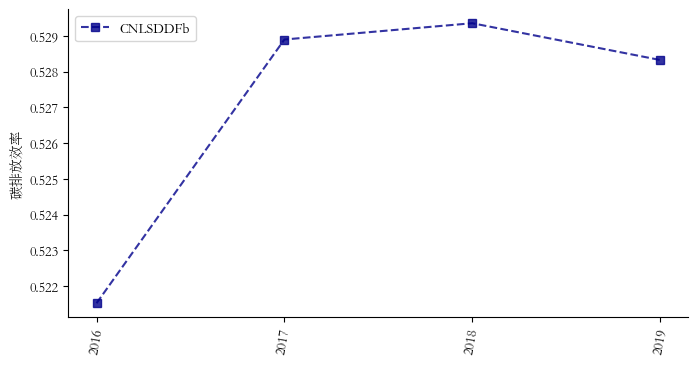

In [75]:
fig, ax = plt.subplots(figsize=(8,4)) # 创建图形网格


ax.spines['top'].set_visible(False) # 使上边框不可见
ax.spines['right'].set_visible(False)
# ax2.spines['right'].set_visible(False)

################################ 绘图 #################################

n_groups = 4  # 分组数量（对应4个年份）
index = np.arange(n_groups)  # 生成x轴位置 [0,1,2,3]
bar_width = 0.5  # 柱状图宽度（虽然实际使用折线图）
# opacity = 0.8 # 设置柱子的透明度
error_config = {'ecolor': 'black','capsize' :2} # 设置误差线为黑色，宽度为2



# 画第一个样本的柱子
rects1 = ax.plot(index, CNLSDDFb_mean_year,
                color='darkblue',alpha = 0.8,linestyle = "dashed",marker = "s",label='CNLSDDFb'
            #      error_kw=error_config,
            #   edgecolor = 'white'
              )
# rects2 = ax.plot(index, MEFFCH_mean_year,
#                 color='olivedrab',alpha = 0.8,linestyle = "dashed",marker = "^",label='MEFFCH'
#             #      error_kw=error_config,
#             #   edgecolor = 'white'
#               )
# rects3 = ax.plot(index, MTECHCH_mean_year,
#                 color='orange',alpha = 0.8,linestyle = "dashed",marker = "+",label='MTECHCH'
#             #      error_kw=error_config,
#             #   edgecolor = 'white'
#               )
###########################################333

# ax.set_xlabel('Hours in 4 ℃')
ax.set_ylabel( '碳排放效率')
#  r'$Difficulty of reducing emissions \gamma$' 
# ax.set_title('Creat by python')
ax.set_xticks(index )
ax.set_xticklabels(xtick2)  # 设置x轴刻度标签（年份）
# ax2.set_xlabel('Relative gene expression')
# ax.spines["bottom"].set_position(("data",0))
plt.legend()  # 显示图例

plt.xticks(rotation=80)  # x轴标签旋转80度防止重叠
# ax.legend(frameon=False,loc='best',ncol = 1)
if kind=="province":
   plt.savefig("chap10分年份碳排放效率-省3.png", dpi=900, bbox_inches = 'tight')
else:
   plt.savefig("chap10分年份碳排放效率-国3.png", dpi=900, bbox_inches = 'tight')
plt.show()  # 显示图形

In [76]:
CNLSDDFb_mean_cou = CNLSDDFb_VRS_DIFF3['TE'].mean(axis=1)


In [77]:
CNLSDDFb_mean_cou

省份
上海市         0.797995
云南省         0.498834
内蒙古自治区      0.195927
北京市         0.809331
吉林省         0.411609
四川省         0.661446
天津市         0.434296
宁夏回族自治区     0.434801
安徽省         0.530416
山东省         0.696224
山西省         0.353426
广东省         0.922558
广西壮族自治区     0.496724
新疆维吾尔自治区    0.274820
江苏省         0.814346
江西省         0.474952
河北省         0.476353
河南省         0.655717
浙江省         0.827339
海南省         0.348638
湖北省         0.646039
湖南省         0.614226
甘肃省         0.286067
福建省         0.659743
贵州省         0.318300
辽宁省         0.501636
重庆市         0.456616
陕西省         0.469358
青海省         0.326754
黑龙江省        0.416310
dtype: float64

In [78]:
CNLSDDFb_mean_cou=CNLSDDFb_mean_cou.sort_values(ascending=False)

In [79]:
CNLSDDFb_mean_cou

省份
广东省         0.922558
浙江省         0.827339
江苏省         0.814346
北京市         0.809331
上海市         0.797995
山东省         0.696224
四川省         0.661446
福建省         0.659743
河南省         0.655717
湖北省         0.646039
湖南省         0.614226
安徽省         0.530416
辽宁省         0.501636
云南省         0.498834
广西壮族自治区     0.496724
河北省         0.476353
江西省         0.474952
陕西省         0.469358
重庆市         0.456616
宁夏回族自治区     0.434801
天津市         0.434296
黑龙江省        0.416310
吉林省         0.411609
山西省         0.353426
海南省         0.348638
青海省         0.326754
贵州省         0.318300
甘肃省         0.286067
新疆维吾尔自治区    0.274820
内蒙古自治区      0.195927
dtype: float64

In [80]:

xtick2 = tuple(CNLSDDFb_mean_cou.index)
xtick2

('广东省',
 '浙江省',
 '江苏省',
 '北京市',
 '上海市',
 '山东省',
 '四川省',
 '福建省',
 '河南省',
 '湖北省',
 '湖南省',
 '安徽省',
 '辽宁省',
 '云南省',
 '广西壮族自治区',
 '河北省',
 '江西省',
 '陕西省',
 '重庆市',
 '宁夏回族自治区',
 '天津市',
 '黑龙江省',
 '吉林省',
 '山西省',
 '海南省',
 '青海省',
 '贵州省',
 '甘肃省',
 '新疆维吾尔自治区',
 '内蒙古自治区')

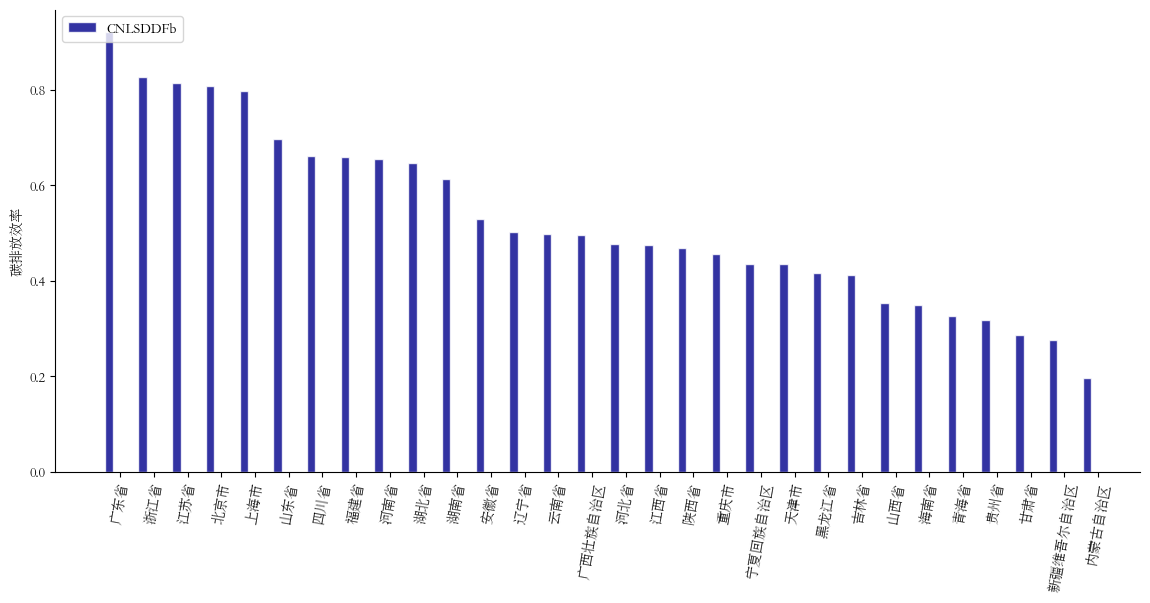

In [81]:
fig, ax = plt.subplots(figsize=(14,6)) # 创建图形网格


ax.spines['top'].set_visible(False) # 使上边框不可见
ax.spines['right'].set_visible(False)
# ax2.spines['right'].set_visible(False)

################################ 绘图 #################################
if kind=="province":
   n_groups = 30 # 样本的数目（ref，mut1-3）
else:
   n_groups = 33  

index = np.arange(n_groups)  # 生成x轴位置 [0,1,2,3]
bar_width = 0.5  # 柱状图宽度（虽然实际使用折线图）
# opacity = 0.8 # 设置柱子的透明度
error_config = {'ecolor': 'black','capsize' :2} # 设置误差线为黑色，宽度为2



# 画第一个样本的柱子
rects1 = ax.bar(index-bar_width/1.5, CNLSDDFb_mean_cou,
                bar_width/2,
                color='darkblue',alpha = 0.8,
                 error_kw=error_config,
              edgecolor = 'white',label='CNLSDDFb'
              )
# rects2 = ax.bar(index , MEFFCH_mean_cou,
#                 bar_width/2,
#                 color='olivedrab',alpha = 0.8,
#                  error_kw=error_config,
#               edgecolor = 'white',label='MEFFCH'
#               )

# rects3 = ax.bar(index+bar_width/1.5, MTECHCH_mean_cou,
#                 bar_width/2,
#                 color='orange',alpha = 0.8,
#                  error_kw=error_config,
#               edgecolor = 'white',label='MTECHCH'
#               )
###########################################333

# ax.set_xlabel('Hours in 4 ℃')
ax.set_ylabel( '碳排放效率')
#  r'$Difficulty of reducing emissions \gamma$' 
# ax.set_title('Creat by python')
ax.set_xticks(index )
ax.set_xticklabels(xtick2)  # 设置x轴刻度标签（年份）
# ax2.set_xlabel('Relative gene expression')
# ax.spines["bottom"].set_position(("data",0))
plt.legend(loc='upper left')#borderaxespad=10,loc='upper right', fontsize='x-large'mode='expand'

plt.xticks(rotation=80)  # x轴标签旋转80度防止重叠
# ax.legend(frameon=False,loc='best',ncol = 1)
if kind=="province":
   plt.savefig("chap10分省份碳排放效率3.png", dpi=900, bbox_inches = 'tight')
else:
   plt.savefig("chap10分国家碳排放效率3.png", dpi=900, bbox_inches = 'tight')

plt.show()  # 显示图形